In [188]:
import numpy as np
import mne
import matplotlib.pyplot as plt

# ==================== CONFIGURATION ====================
fname = r"D:/Semester 5/4. ASN/ASN Pak Adib/EEG/BCICIV_2b_gdf/B0101T.gdf"

# Parameter Filter
lpf_cutoff = 30.0   
hpf_cutoff = 8.0    
filter_order = 2    

# Parameter Plotting
plot_start_sec = 60
plot_duration = 10

# ==================== 1. LOAD DATA & EVENTS ====================
plt.style.use('seaborn-v0_8-darkgrid')
mne.set_log_level('WARNING')

print(f"Loading data from: {fname}")
try:
    raw = mne.io.read_raw_gdf(fname, preload=True)
except FileNotFoundError:
    print("File tidak ditemukan. Cek path file.")
    exit()

eog_channels = ['EOG:ch01', 'EOG:ch02', 'EOG:ch03']
raw.drop_channels([ch for ch in eog_channels if ch in raw.ch_names], on_missing='ignore')

Fs = raw.info['sfreq']
print(f"Sampling Frequency: {Fs} Hz")

events = mne.events_from_annotations(raw)
events_array = events[0]
event_dict = events[1]

# Pencarian ID Event (Left/Right)
left_id = None
right_id = None
for event_name, event_id in event_dict.items():
    name_lower = event_name.lower()
    if 'left' in name_lower or '769' in name_lower or event_id == 769: left_id = event_id
    elif 'right' in name_lower or '770' in name_lower or event_id == 770: right_id = event_id

if left_id is None or right_id is None:
    for event_name, event_id in event_dict.items():
        if '1' in event_name: left_id = event_id
        elif '2' in event_name: right_id = event_id

if left_id and right_id:
    events_motor = events_array[(events_array[:, 2] == left_id) | (events_array[:, 2] == right_id)]
    print(f"Events found: Left ID={left_id}, Right ID={right_id}")
else:
    events_motor = events_array

# ==================== 2. MANUAL FILTER FUNCTIONS ====================
def butterworth_lpf(signal, freq_cutoff, orde):
    omega_c = 2 * np.pi * freq_cutoff
    Ts = 1 / Fs
    Ts2 = Ts ** 2
    wc2 = omega_c ** 2
    y = np.zeros(len(signal))

    if orde == 2:
        k1 = 4/Ts2
        k2 = 2*np.sqrt(2)*omega_c/Ts
        norm = k1 + k2 + wc2
        b0 = wc2 / norm
        b1 = 2 * b0
        b2 = b0
        a1 = (2*wc2 - 2*k1) / norm
        a2 = (k1 - k2 + wc2) / norm
        
        for n in range(len(signal)):
            if n < 2: y[n] = b0*signal[n]
            else: y[n] = b0*signal[n] + b1*signal[n-1] + b2*signal[n-2] - a1*y[n-1] - a2*y[n-2]
    return y

def butterworth_hpf(signal, freq_cutoff, orde):
    omega_c = 2 * np.pi * freq_cutoff
    Ts = 1 / Fs
    Ts2 = Ts**2
    wc2 = omega_c**2
    y = np.zeros(len(signal))

    if orde == 2:
        k1 = 4/Ts2
        k2 = 2*np.sqrt(2)*omega_c/Ts
        norm = wc2 + k2 + k1
        b0 = k1 / norm
        b1 = -2 * b0
        b2 = b0
        a1 = (2*wc2 - 2*k1) / norm
        a2 = (wc2 - k2 + k1) / norm

        for n in range(len(signal)):
            if n < 2: y[n] = b0*signal[n]
            else: y[n] = b0*signal[n] + b1*signal[n-1] + b2*signal[n-2] - a1*y[n-1] - a2*y[n-2]
    return y

# ==================== 3. MANUAL FFT IMPLEMENTATION ====================
def next_power_of_2(x):
    """Mencari angka pangkat 2 terdekat di atas x"""
    return 1 if x == 0 else 2**(x - 1).bit_length()

def fft(x):
    N = len(x)
    if N <= 1:
        return x
    even = fft(x[0::2])
    odd = fft(x[1::2])

    factor = np.exp(-2j * np.pi * np.arange(N // 2) / N)
    
    return np.concatenate([even + factor * odd, even - factor * odd])

# ==================== 4. MANUAL PSD WELCH ====================
def calc_psd_manual_welch(signal, fs, window_size_sec=2.0, overlap=0.5):

    N_window = int(window_size_sec * fs)
    step = int(N_window * (1 - overlap))
    
    # FFT Manual butuh input panjangnya pangkat 2
    # Kita cari pangkat 2 terdekat, misal window=500 -> N_pad=512
    N_pad = next_power_of_2(N_window)
    
    window = np.hanning(N_window)
    # Scaling factor energi window
    scale = 1.0 / (fs * np.sum(window**2))
    
    psd_list = []
    
    for start in range(0, len(signal) - N_window, step):
        segment = signal[start : start + N_window]
        segment_windowed = segment * window
        
        # Zero Padding Manual: Tambah nol di akhir agar panjangnya jadi N_pad
        # Ini syarat wajib algoritma Cooley-Tukey
        padded_segment = np.zeros(N_pad)
        padded_segment[:N_window] = segment_windowed
        
        # --- PANGGIL FFT MANUAL ---
        fft_vals = fft(padded_segment)
        # --------------------------
        
        # Ambil frekuensi positif saja (N/2 + 1)
        half_idx = N_pad // 2 + 1
        
        # Hitung Power
        psd_segment = (np.abs(fft_vals[:half_idx]) ** 2) * scale
        psd_segment[1:-1] *= 2 # Koreksi one-sided
        
        psd_list.append(psd_segment)
    
    if len(psd_list) == 0: return np.array([]), np.array([])
    psd_avg = np.mean(psd_list, axis=0)

    freqs = np.array([k * fs / N_pad for k in range(half_idx)])
    
    return freqs, psd_avg

data_raw, times = raw[:, :]
data_raw = data_raw * 1e6 

channels_to_plot = [0, 1, 2] # C3, Cz, C4
channel_labels = [raw.ch_names[i] for i in channels_to_plot]
data_filtered = np.zeros((len(channels_to_plot), data_raw.shape[1]))

for idx, ch_idx in enumerate(channels_to_plot):
    signal = data_raw[ch_idx, :]

    hpf_fwd = butterworth_hpf(signal, hpf_cutoff, filter_order)
    lpf_fwd = butterworth_lpf(hpf_fwd, lpf_cutoff, filter_order)
    
    hpf_bwd = butterworth_hpf(lpf_fwd[::-1], hpf_cutoff, filter_order)
    lpf_bwd = butterworth_lpf(hpf_bwd, lpf_cutoff, filter_order)
    
    data_filtered[idx, :] = lpf_bwd[::-1]



Loading data from: D:/Semester 5/4. ASN/ASN Pak Adib/EEG/BCICIV_2b_gdf/B0101T.gdf


C:\Users\ACER\AppData\Local\Temp\ipykernel_49572\3317235466.py:23: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(fname, preload=True)


Sampling Frequency: 250.0 Hz
Events found: Left ID=10, Right ID=11


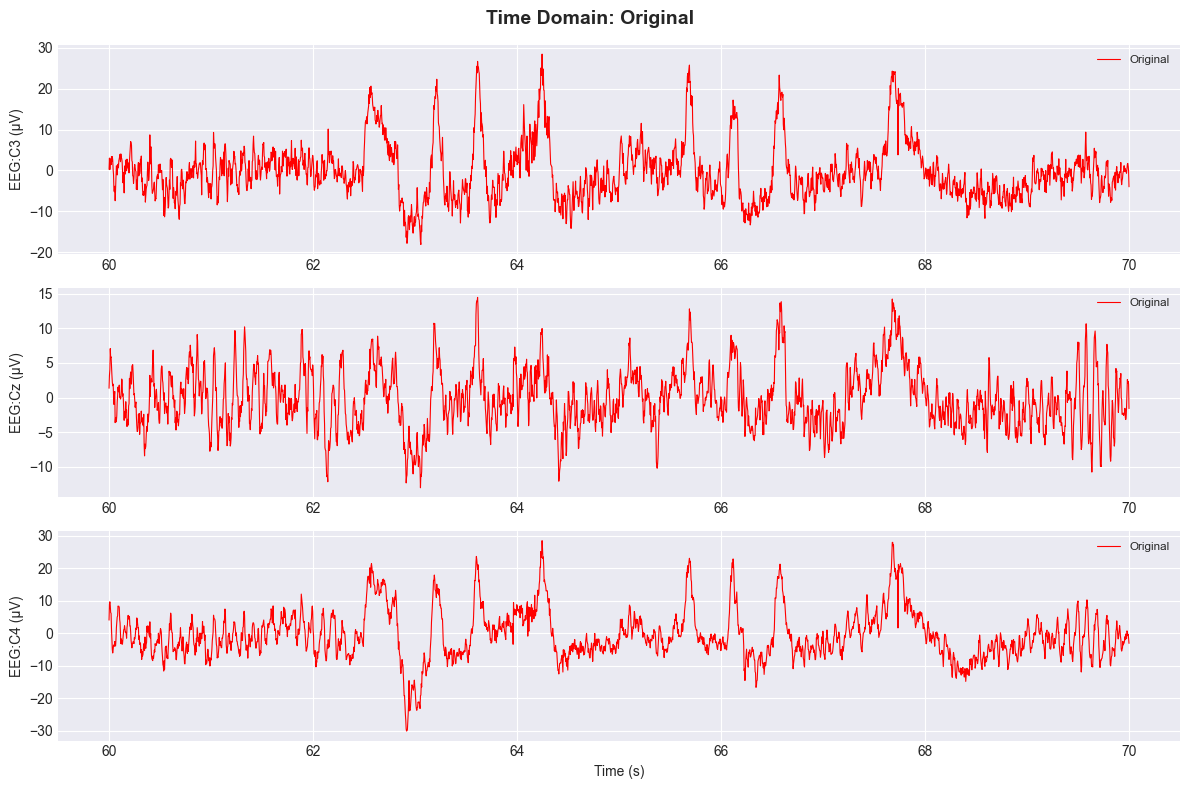

In [189]:
# ==================== 6. PLOTTING ====================
start_idx = int(plot_start_sec * Fs)
end_idx = int((plot_start_sec + plot_duration) * Fs)
time_segment = np.arange(start_idx, end_idx) / Fs

# Plot 1: Time Domain
fig1, axes = plt.subplots(len(channels_to_plot), 1, figsize=(12, 8))
fig1.suptitle(f'Time Domain: Original  ', fontsize=14, fontweight='bold')

for idx, ch_idx in enumerate(channels_to_plot):
    axes[idx].plot(time_segment, data_raw[ch_idx, start_idx:end_idx], 
                   label='Original', color='red', linewidth=0.8)
    
    
    events_in_window = events_motor[(events_motor[:, 0] >= start_idx) & (events_motor[:, 0] < end_idx)]
    for event in events_in_window:
        t_ev = event[0]/Fs
        c_ev = 'red' if event[2] == left_id else 'green'
        axes[idx].axvline(x=t_ev, color=c_ev, linestyle='--', alpha=0.8)

    axes[idx].set_ylabel(f'{channel_labels[idx]} (µV)')
    axes[idx].legend(loc='upper right', fontsize='small')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()



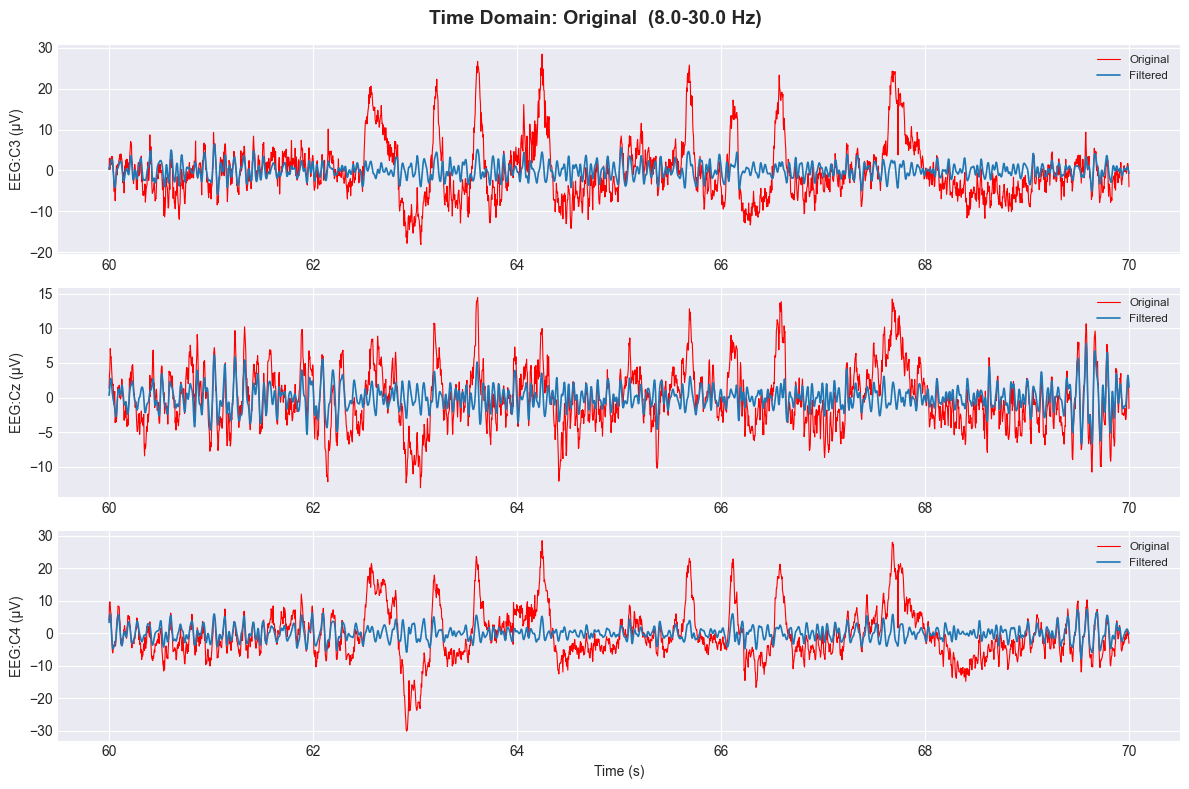

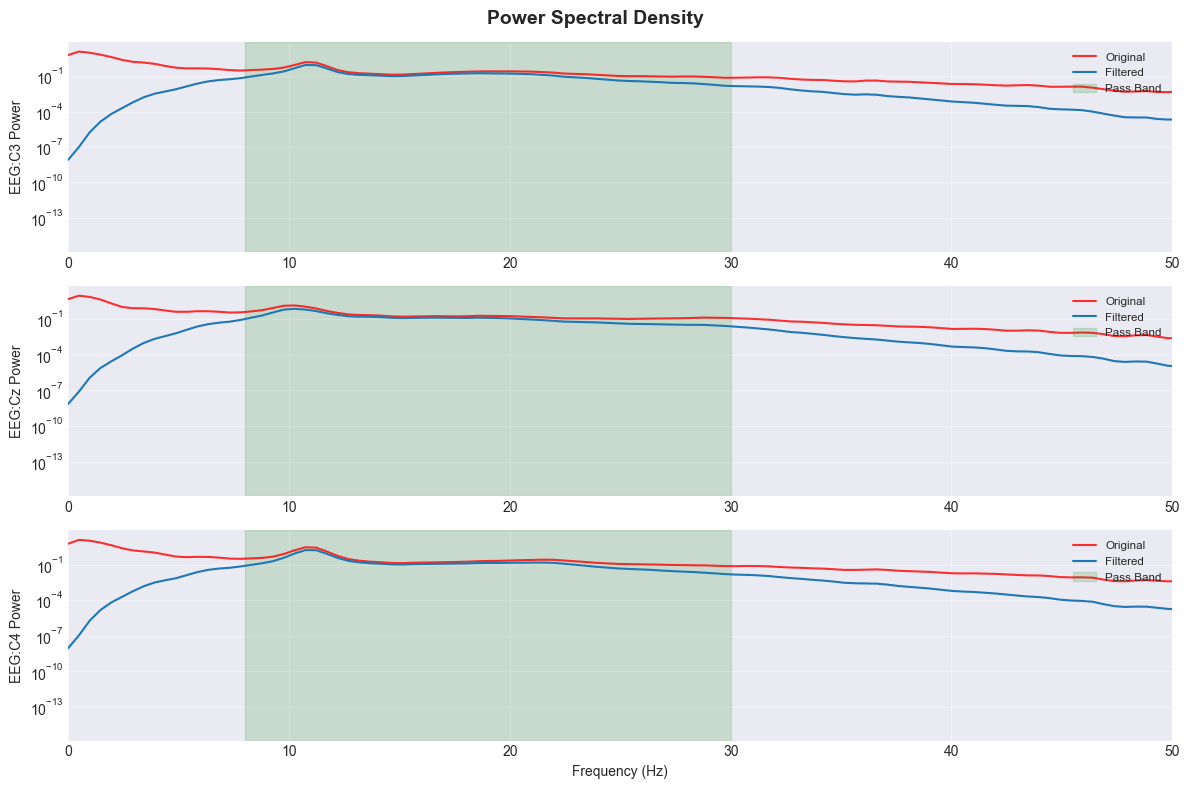

In [190]:
# ==================== 6. PLOTTING ====================
start_idx = int(plot_start_sec * Fs)
end_idx = int((plot_start_sec + plot_duration) * Fs)
time_segment = np.arange(start_idx, end_idx) / Fs

# Plot 1: Time Domain
fig1, axes = plt.subplots(len(channels_to_plot), 1, figsize=(12, 8))
fig1.suptitle(f'Time Domain: Original  ({hpf_cutoff}-{lpf_cutoff} Hz)', fontsize=14, fontweight='bold')

for idx, ch_idx in enumerate(channels_to_plot):
    axes[idx].plot(time_segment, data_raw[ch_idx, start_idx:end_idx], 
                   label='Original', color='red', linewidth=0.8)
    axes[idx].plot(time_segment, data_filtered[idx, start_idx:end_idx], 
                   label='Filtered', color='#1f77b4', linewidth=1.2)
    
    events_in_window = events_motor[(events_motor[:, 0] >= start_idx) & (events_motor[:, 0] < end_idx)]
    for event in events_in_window:
        t_ev = event[0]/Fs
        c_ev = 'red' if event[2] == left_id else 'green'
        axes[idx].axvline(x=t_ev, color=c_ev, linestyle='--', alpha=0.8)

    axes[idx].set_ylabel(f'{channel_labels[idx]} (µV)')
    axes[idx].legend(loc='upper right', fontsize='small')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
fig2, axes = plt.subplots(len(channels_to_plot), 1, figsize=(12, 8))
fig2.suptitle('Power Spectral Density', fontsize=14, fontweight='bold')

for idx, ch_idx in enumerate(channels_to_plot):
    # Hitung PSD Manual
    freqs_orig, psd_orig = calc_psd_manual_welch(data_raw[ch_idx, :], Fs)
    freqs_filt, psd_filt = calc_psd_manual_welch(data_filtered[idx, :], Fs)
    
    # Plotting
    axes[idx].semilogy(freqs_orig, psd_orig, label='Original', color='red', alpha=0.8)
    axes[idx].semilogy(freqs_filt, psd_filt, label='Filtered', color='#1f77b4', linewidth=1.5)
    
    axes[idx].axvspan(hpf_cutoff, lpf_cutoff, color='green', alpha=0.15, label='Pass Band')
    
    axes[idx].set_ylabel(f'{channel_labels[idx]} Power')
    axes[idx].set_xlim(0, 50) 
    axes[idx].legend(loc='upper right', fontsize='small')
    axes[idx].grid(True, which="both", ls="-", alpha=0.5)

axes[-1].set_xlabel('Frequency (Hz)')
plt.tight_layout()

plt.show()

Power signal computed (element-wise squaring)
Power data shape: (3, 604803)
Power range: [0.00, 1214.39] µV²
MAV window: 100 ms = 25 samples


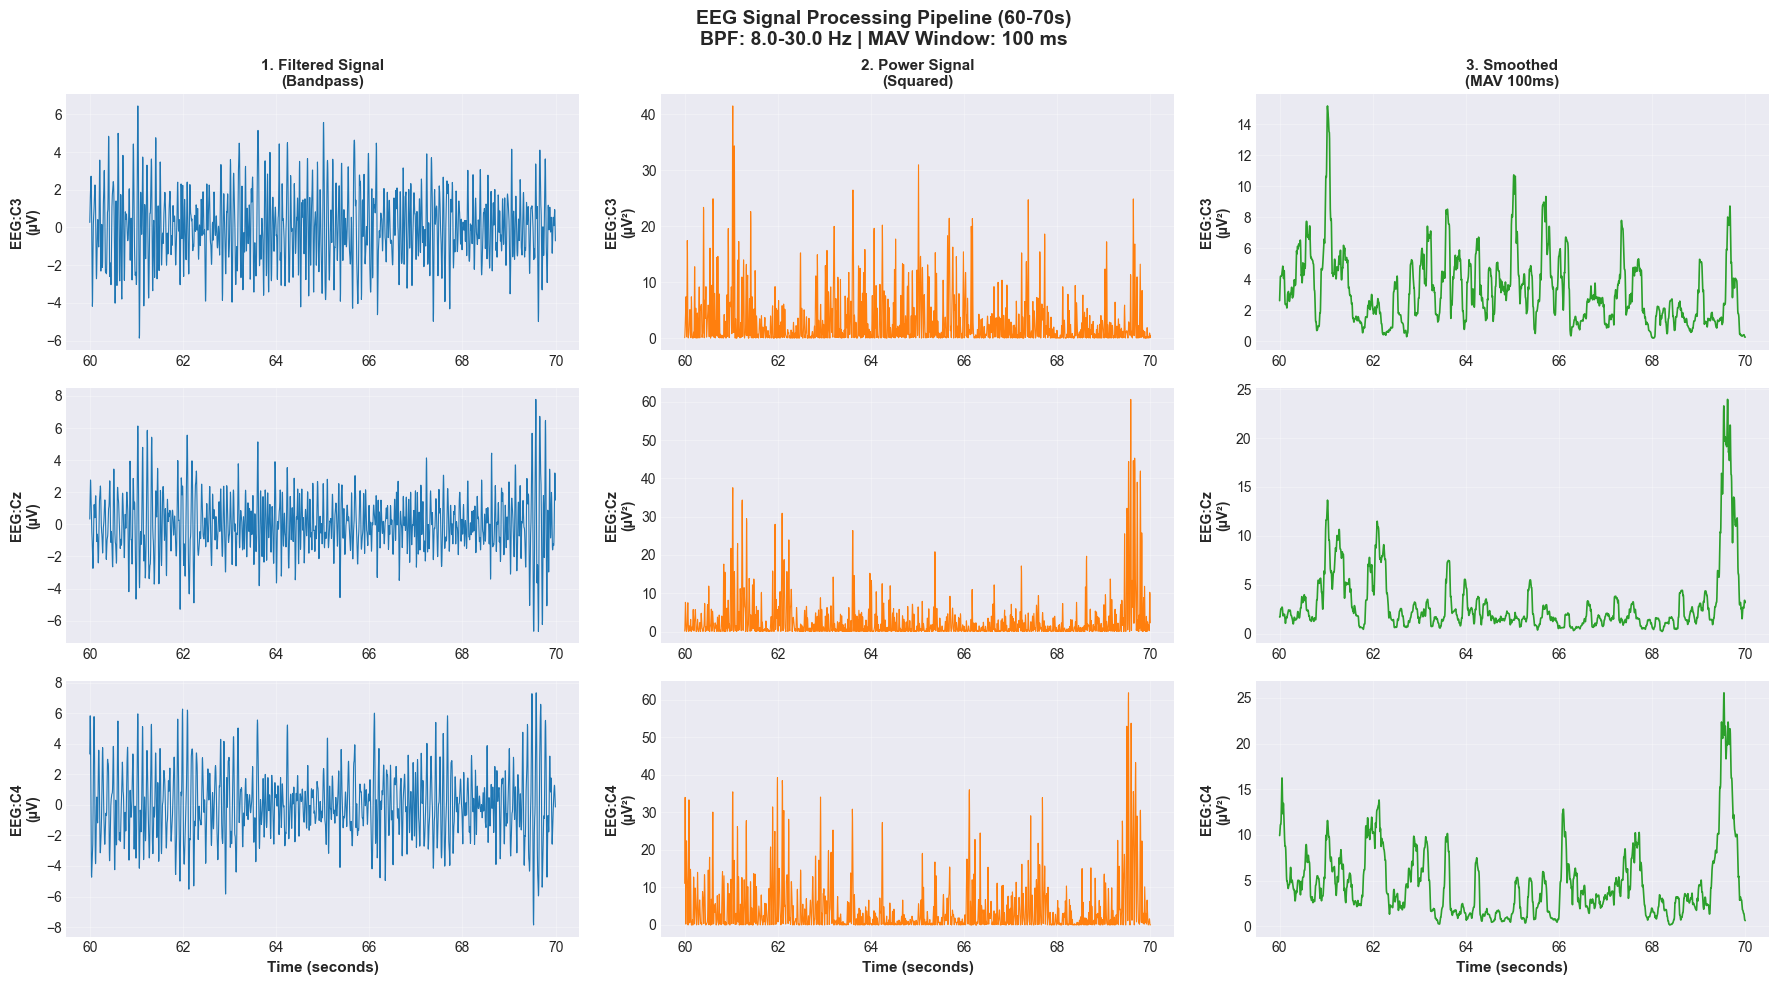

In [191]:

data_power = data_filtered ** 2

print(f"Power signal computed (element-wise squaring)")
print(f"Power data shape: {data_power.shape}")
print(f"Power range: [{np.min(data_power):.2f}, {np.max(data_power):.2f}] µV²")


mav_window_ms = 100  # 100 ms
mav_window_samples = int(mav_window_ms * Fs / 1000)

print(f"MAV window: {mav_window_ms} ms = {mav_window_samples} samples")

def moving_average(signal, window_size):
    """Compute moving average using convolution"""
    kernel = np.ones(window_size) / window_size
    # Use 'same' mode to keep same length
    smoothed = np.convolve(signal, kernel, mode='same')
    return smoothed

# Apply MAV to all channels
data_smoothed = np.zeros_like(data_power)

for ch_idx in range(data_power.shape[0]):
    print(f"Smoothing channel {ch_idx+1}/{data_power.shape[0]}: {raw.ch_names[ch_idx]}...", end='\r')
    data_smoothed[ch_idx, :] = moving_average(data_power[ch_idx, :], mav_window_samples)

# Pilih 3 channel untuk visualisasi (C3, Cz, C4)
channels_to_plot = [0, 1, 2]
channel_labels = [raw.ch_names[i] for i in channels_to_plot]

# Time window untuk visualisasi
start_sec = 60
duration_sec = 10
start_idx = int(start_sec * Fs)
end_idx = int((start_sec + duration_sec) * Fs)
time_segment = np.arange(start_idx, end_idx) / Fs

# Plot: Processing Pipeline (Filtered → Power → Smoothed)
fig, axes = plt.subplots(len(channels_to_plot), 3, figsize=(18, 10))
fig.suptitle(f'EEG Signal Processing Pipeline ({start_sec}-{start_sec+duration_sec}s)\n' + 
             f'BPF: {hpf_cutoff}-{lpf_cutoff} Hz | MAV Window: {mav_window_ms} ms',
             fontsize=14, fontweight='bold')

for idx, ch_idx in enumerate(channels_to_plot):
    # Column 1: Filtered Signal
    axes[idx, 0].plot(time_segment, data_filtered[ch_idx, start_idx:end_idx], 
                      color='tab:blue', linewidth=0.8)
    axes[idx, 0].set_ylabel(f'{channel_labels[idx]}\n(µV)', fontsize=10, fontweight='bold')
    if idx == 0:
        axes[idx, 0].set_title('1. Filtered Signal\n(Bandpass)', fontsize=11, fontweight='bold')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Column 2: Power Signal (Squared)
    axes[idx, 1].plot(time_segment, data_power[ch_idx, start_idx:end_idx], 
                      color='tab:orange', linewidth=0.8)
    axes[idx, 1].set_ylabel(f'{channel_labels[idx]}\n(µV²)', fontsize=10, fontweight='bold')
    if idx == 0:
        axes[idx, 1].set_title('2. Power Signal\n(Squared)', fontsize=11, fontweight='bold')
    axes[idx, 1].grid(True, alpha=0.3)
    
    # Column 3: Smoothed (MAV)
    axes[idx, 2].plot(time_segment, data_smoothed[ch_idx, start_idx:end_idx], 
                      color='tab:green', linewidth=1.2)
    axes[idx, 2].set_ylabel(f'{channel_labels[idx]}\n(µV²)', fontsize=10, fontweight='bold')
    if idx == 0:
        axes[idx, 2].set_title(f'3. Smoothed\n(MAV {mav_window_ms}ms)', fontsize=11, fontweight='bold')
    axes[idx, 2].grid(True, alpha=0.3)
    
    # Add event markers to all columns
    events_in_window = events_motor[(events_motor[:, 0] >= start_idx) & 
                                     (events_motor[:, 0] < end_idx)]
    for col in range(3):
        for event in events_in_window:
            event_time = event[0] / Fs
            event_id = event[2]
            color = 'red' if event_id == left_id else 'green'
            axes[idx, col].axvline(x=event_time, color=color, linestyle='--', 
                                   alpha=0.5, linewidth=1.5)

# Set x-labels
for col in range(3):
    axes[-1, col].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


  Left hand events: 60
  Right hand events: 60

Epoch shapes:
  Baseline: (60, 3, 750)
  Test: (60, 3, 750)

Calculating ERD/ERS percentage...

Average ERD/ERS:
  Left: (3, 750)
  Right: (3, 750)

Average power shapes:
  Baseline left: (3, 750)
  Test left: (3, 750)

Full signal shapes:
  Left: (3, 1500)
  Right: (3, 1500)

Full ERD/ERS shapes:
  Left: (3, 1500)
  Right: (3, 1500)

Time axis:
  Length: 1500
  Range: -3.00 to 3.00 seconds


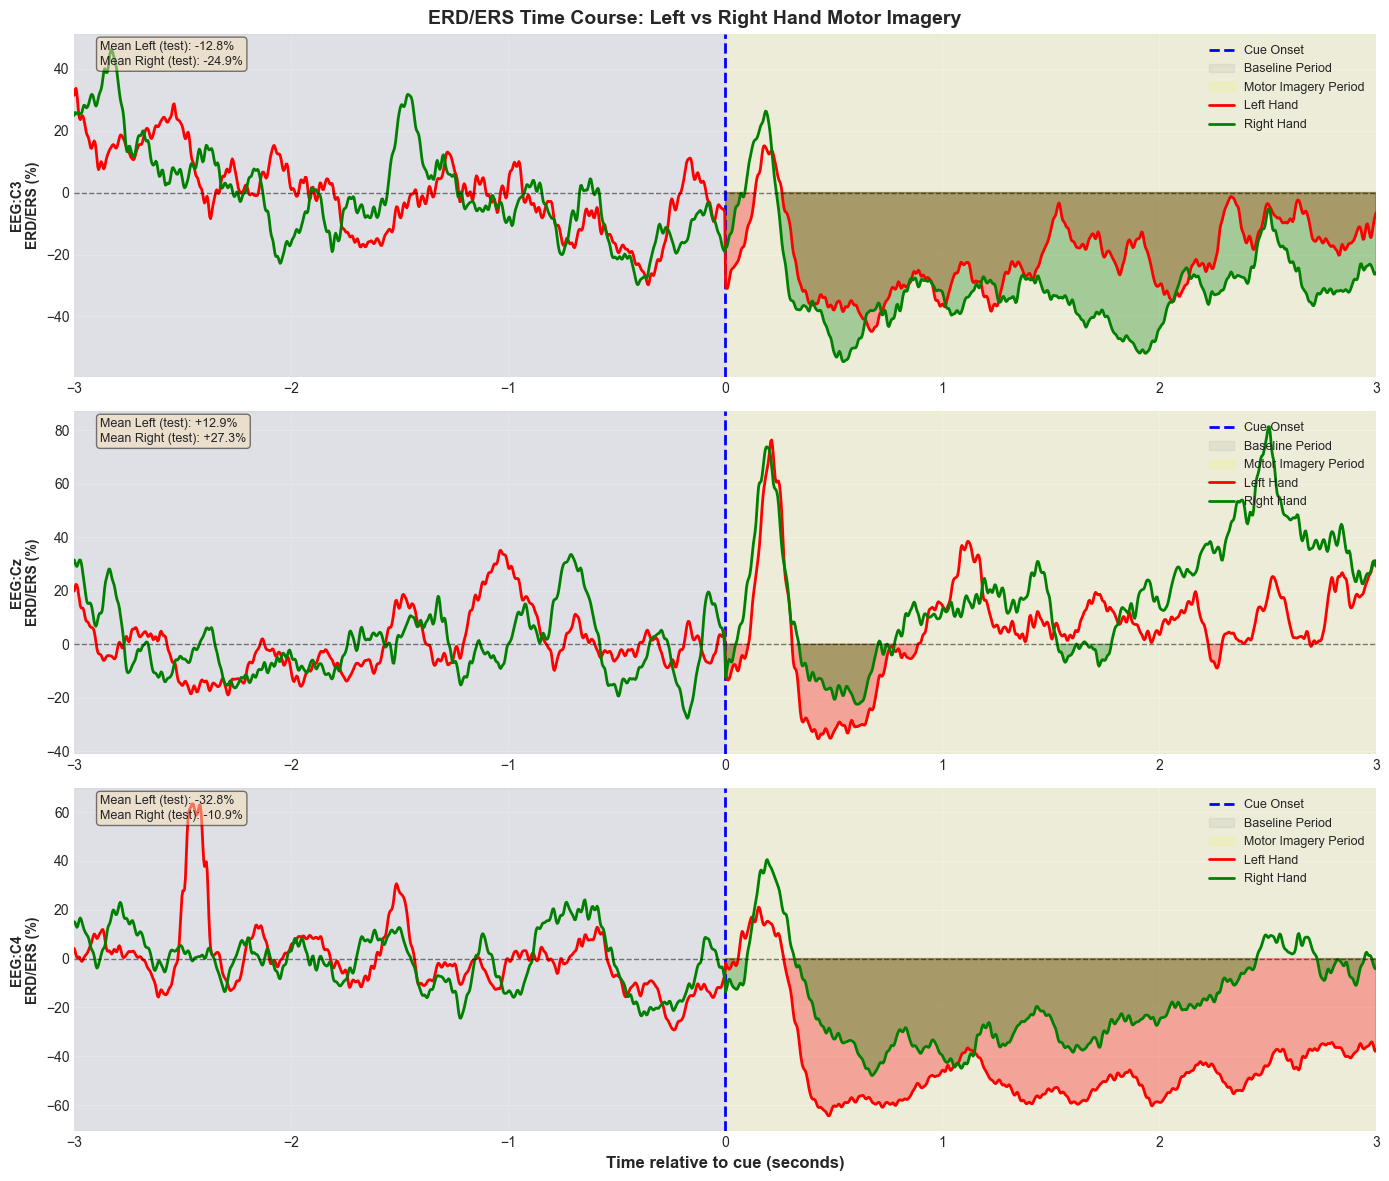

Right Hand Motor Imagery


In [198]:
baseline_duration = 3  # 1 detik sebelum cue sebagai baseline/reference
test_start = 0.2        
test_duration = 3      # 3 detik test window

# Hitung sample indices untuk windows
baseline_samples = int(baseline_duration * Fs)
test_start_samples = int(test_start * Fs)
test_end_samples = int((test_start + test_duration) * Fs)

# Pisahkan events berdasarkan class
events_left = events_motor[events_motor[:, 2] == left_id]  # Left hand
events_right = events_motor[events_motor[:, 2] == right_id]  # Right hand

print(f"  Left hand events: {len(events_left)}")
print(f"  Right hand events: {len(events_right)}")

# Storage untuk epochs
n_channels = data_smoothed.shape[0]

epochs_left_baseline = []
epochs_left_test = []
epochs_right_baseline = []
epochs_right_test = []

for i, event in enumerate(events_left):
    cue_sample = event[0]
    
    # Baseline window (sebelum cue)
    baseline_start = cue_sample - baseline_samples
    baseline_end = cue_sample
    
    # Test window (setelah cue)
    test_start_idx = cue_sample + test_start_samples
    test_end_idx = cue_sample + test_end_samples
    
    # Pastikan indices valid
    if baseline_start >= 0 and test_end_idx < data_smoothed.shape[1]:
        baseline_epoch = data_smoothed[:, baseline_start:baseline_end]
        test_epoch = data_smoothed[:, test_start_idx:test_end_idx]
        
        epochs_left_baseline.append(baseline_epoch)
        epochs_left_test.append(test_epoch)


for i, event in enumerate(events_right):
    cue_sample = event[0]
    
    baseline_start = cue_sample - baseline_samples
    baseline_end = cue_sample
    test_start_idx = cue_sample + test_start_samples
    test_end_idx = cue_sample + test_end_samples
    
    if baseline_start >= 0 and test_end_idx < data_smoothed.shape[1]:
        baseline_epoch = data_smoothed[:, baseline_start:baseline_end]
        test_epoch = data_smoothed[:, test_start_idx:test_end_idx]
        
        epochs_right_baseline.append(baseline_epoch)
        epochs_right_test.append(test_epoch)

# Convert to arrays
epochs_left_baseline = np.array(epochs_left_baseline)
epochs_left_test = np.array(epochs_left_test)
epochs_right_baseline = np.array(epochs_right_baseline)
epochs_right_test = np.array(epochs_right_test)

print(f"\nEpoch shapes:")
print(f"  Baseline: {epochs_left_baseline.shape}")
print(f"  Test: {epochs_left_test.shape}")

# ==================== CALCULATE ERD/ERS ====================
print(f"\nCalculating ERD/ERS percentage...")

def calculate_erd_ers(baseline_epochs, test_epochs):
    n_trials = baseline_epochs.shape[0]
    n_channels = baseline_epochs.shape[1]
    n_samples_test = test_epochs.shape[2]
    
    erd_ers = np.zeros_like(test_epochs)
    
    for trial in range(n_trials):
        for ch in range(n_channels):
            baseline_power = np.mean(baseline_epochs[trial, ch, :])
            
            if baseline_power < 1e-10:
                baseline_power = 1e-10
            
            for t in range(n_samples_test):
                test_power = test_epochs[trial, ch, t]
                erd_ers[trial, ch, t] = ((test_power - baseline_power) / baseline_power) * 100
    
    return erd_ers

erd_ers_left = calculate_erd_ers(epochs_left_baseline, epochs_left_test)
erd_ers_right = calculate_erd_ers(epochs_right_baseline, epochs_right_test)

# Average across trials
erd_ers_left_avg = np.mean(erd_ers_left, axis=0)
erd_ers_right_avg = np.mean(erd_ers_right, axis=0)

print(f"\nAverage ERD/ERS:")
print(f"  Left: {erd_ers_left_avg.shape}")
print(f"  Right: {erd_ers_right_avg.shape}")

# ============ PERBAIKAN: Gabungkan baseline dan test untuk visualisasi ============
# Hitung average baseline dan test (dalam domain power, bukan ERD/ERS dulu)
baseline_left_avg = np.mean(epochs_left_baseline, axis=0)  # (n_channels, baseline_samples)
baseline_right_avg = np.mean(epochs_right_baseline, axis=0)
test_left_avg = np.mean(epochs_left_test, axis=0)  # (n_channels, test_samples)
test_right_avg = np.mean(epochs_right_test, axis=0)

print(f"\nAverage power shapes:")
print(f"  Baseline left: {baseline_left_avg.shape}")
print(f"  Test left: {test_left_avg.shape}")

# Gabungkan baseline dan test
full_left = np.concatenate([baseline_left_avg, test_left_avg], axis=1)
full_right = np.concatenate([baseline_right_avg, test_right_avg], axis=1)

print(f"\nFull signal shapes:")
print(f"  Left: {full_left.shape}")
print(f"  Right: {full_right.shape}")

# Hitung ERD/ERS untuk seluruh timeline
def calculate_erd_ers_full(full_data, baseline_samples):
    n_channels = full_data.shape[0]
    n_samples = full_data.shape[1]
    erd_ers_full = np.zeros_like(full_data)
    
    for ch in range(n_channels):
        baseline_power = np.mean(full_data[ch, :baseline_samples])
        
        if baseline_power < 1e-10:
            baseline_power = 1e-10
        
        for t in range(n_samples):
            test_power = full_data[ch, t]
            erd_ers_full[ch, t] = ((test_power - baseline_power) / baseline_power) * 100
    
    return erd_ers_full

erd_ers_left_full = calculate_erd_ers_full(full_left, baseline_samples)
erd_ers_right_full = calculate_erd_ers_full(full_right, baseline_samples)

print(f"\nFull ERD/ERS shapes:")
print(f"  Left: {erd_ers_left_full.shape}")
print(f"  Right: {erd_ers_right_full.shape}")

# ============ PERBAIKAN: Time axis yang sesuai dengan data ============
# Total samples = baseline_samples + test_samples
total_samples = erd_ers_left_full.shape[1]
time_axis = np.linspace(-baseline_duration, test_duration, total_samples)

print(f"\nTime axis:")
print(f"  Length: {len(time_axis)}")
print(f"  Range: {time_axis[0]:.2f} to {time_axis[-1]:.2f} seconds")

# Select channels for visualization
channels_to_plot = [0, 1, 2]  # C3, Cz, C4
channel_labels = [raw.ch_names[i] for i in channels_to_plot]
n_plot_channels = len(channels_to_plot)

# ========== PLOT: ERD/ERS TIME COURSE ==========
fig1, axes = plt.subplots(n_plot_channels, 1, figsize=(14, 4*n_plot_channels))
if n_plot_channels == 1:
    axes = [axes]

fig1.suptitle('ERD/ERS Time Course: Left vs Right Hand Motor Imagery', 
              fontsize=14, fontweight='bold')

for idx, ch_idx in enumerate(channels_to_plot):
    # Cue onset di x=0
    axes[idx].axvline(
        x=0,
        color='blue',
        linestyle='--',
        linewidth=2,
        label='Cue Onset'
    )
    
    # Shading untuk baseline dan motor imagery period
    axes[idx].axvspan(-baseline_duration, 0, alpha=0.1, color='gray', label='Baseline Period')
    axes[idx].axvspan(0, test_duration, alpha=0.1, color='yellow', label='Motor Imagery Period')

    # Plot Left hand
    axes[idx].plot(time_axis, erd_ers_left_full[ch_idx, :], 
                   label='Left Hand', color='red', linewidth=2)
    
    # Plot Right hand
    axes[idx].plot(time_axis, erd_ers_right_full[ch_idx, :], 
                   label='Right Hand', color='green', linewidth=2)
    
    # Zero line
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Shading untuk ERD (negative) hanya di test period
    test_mask = time_axis >= 0
    axes[idx].fill_between(time_axis[test_mask], 0, erd_ers_left_full[ch_idx, test_mask], 
                           where=(erd_ers_left_full[ch_idx, test_mask] < 0), 
                           alpha=0.3, color='red', interpolate=True)
    axes[idx].fill_between(time_axis[test_mask], 0, erd_ers_right_full[ch_idx, test_mask], 
                           where=(erd_ers_right_full[ch_idx, test_mask] < 0), 
                           alpha=0.3, color='green', interpolate=True)
    
    axes[idx].set_ylabel(f'{channel_labels[idx]}\nERD/ERS (%)', 
                         fontsize=10, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='upper right', fontsize=9)
    axes[idx].set_xlim([time_axis[0], time_axis[-1]])
    
    # Mean values (dari test period saja)
    left_mean = np.mean(erd_ers_left_avg[ch_idx, :])
    right_mean = np.mean(erd_ers_right_avg[ch_idx, :])
    axes[idx].text(0.02, 0.98, f'Mean Left (test): {left_mean:+.1f}%\nMean Right (test): {right_mean:+.1f}%',
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1].set_xlabel('Time relative to cue (seconds)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

if event_name == '769':
    event_name = 'Left Hand Motor Imagery'
elif event_name == '770':
    event_name = 'Right Hand Motor Imagery'
print(event_name)


==================== STATISTICAL FEATURE EXTRACTION (MANUAL) ====================

--- Average Feature Values per Channel (Left vs Right) ---
Channel  Feature  Left Hand (Avg)  Right Hand (Avg)  Diff (L-R)
 EEG:C3     Mean           2.4498            2.0746      0.3753
 EEG:C3 Variance           3.9271            3.0485      0.8786
 EEG:C3 Skewness           1.3945            1.6062     -0.2117
 EEG:C3 Kurtosis           2.0557            3.3222     -1.2664
 EEG:Cz     Mean           3.1362            3.3897     -0.2535
 EEG:Cz Variance           5.0229            6.6411     -1.6182
 EEG:Cz Skewness           1.2636            1.3000     -0.0364
 EEG:Cz Kurtosis           1.7884            1.7724      0.0159
 EEG:C4     Mean           2.3754            3.3308     -0.9554
 EEG:C4 Variance           5.0375            9.1653     -4.1278
 EEG:C4 Skewness           1.6657            1.5727      0.0930
 EEG:C4 Kurtosis           3.2712            3.0251      0.2462


C:\Users\ACER\AppData\Local\Temp\ipykernel_49572\2741558862.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot([data_left, data_right],
C:\Users\ACER\AppData\Local\Temp\ipykernel_49572\2741558862.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot([data_left, data_right],
C:\Users\ACER\AppData\Local\Temp\ipykernel_49572\2741558862.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot([data_left, data_right],
C:\Users\ACER\AppData\Local\Temp\ipykernel_49572\2741558862.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tic

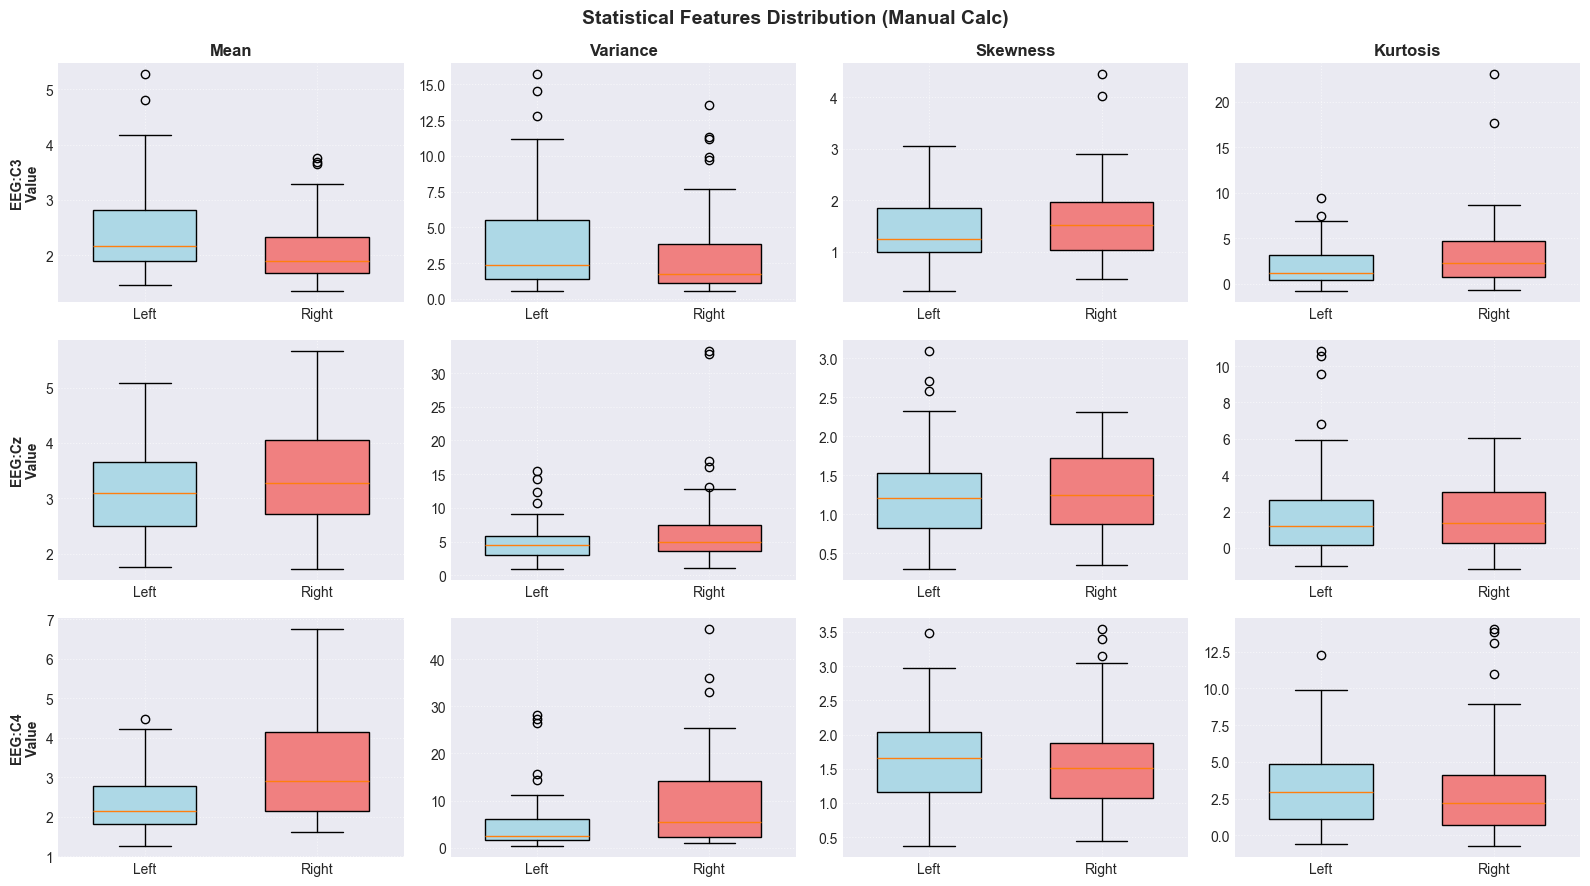

In [193]:
# ==================== FEATURE EXTRACTION (MANUAL NUMPY) ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"\n{'='*20} STATISTICAL FEATURE EXTRACTION (MANUAL) {'='*20}")

def extract_features_manual(epochs_data):
    # 1. MEAN (Rata-rata)
    mu = np.mean(epochs_data, axis=2, keepdims=True)
    centered = epochs_data - mu
    
    # 2. VARIANCE (Variansi - Momen ke-2)
    # Rata-rata dari kuadrat selisih
    var = np.mean(centered**2, axis=2)
    std = np.sqrt(var)
    std[std == 0] = 1e-10 
    
    # 3. SKEWNESS (Kemiringan - Momen ke-3 ternormalisasi)
    moment3 = np.mean(centered**3, axis=2)
    skew = moment3 / (std**3)
    
    # 4. KURTOSIS (Keruncingan - Momen ke-4 ternormalisasi - 3)
    moment4 = np.mean(centered**4, axis=2)
    kurt = (moment4 / (std**4)) - 3
    
    # Kembalikan mu ke bentuk (n_trials, n_channels)
    mu = mu.reshape(epochs_data.shape[0], epochs_data.shape[1])
    
    return {
        'mean': mu,
        'variance': var,
        'skewness': skew,
        'kurtosis': kurt
    }

# 1. Ekstrak fitur untuk Left dan Right
features_left = extract_features_manual(epochs_left_test)
features_right = extract_features_manual(epochs_right_test)

# 2. Tampilkan Rata-rata Fitur per Channel
feature_names = ['mean', 'variance', 'skewness', 'kurtosis']
selected_channels = [0, 1, 2] # C3, Cz, C4 (sesuaikan index channel)

print("\n--- Average Feature Values per Channel (Left vs Right) ---")

results_data = []

for ch_idx in selected_channels:
    ch_name = raw.ch_names[ch_idx]
    
    for feat in feature_names:
        # Ambil rata-rata dari semua trial
        val_left = np.mean(features_left[feat][:, ch_idx])
        val_right = np.mean(features_right[feat][:, ch_idx])
        
        results_data.append({
            'Channel': ch_name,
            'Feature': feat.capitalize(),
            'Left Hand (Avg)': val_left,
            'Right Hand (Avg)': val_right,
            'Diff (L-R)': val_left - val_right
        })

df_results = pd.DataFrame(results_data)
# Tampilkan tabel
print(df_results.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))


# ==================== PLOT FEATURE DISTRIBUTIONS ====================
fig2, axes = plt.subplots(len(selected_channels), 4, figsize=(16, 3*len(selected_channels)))
fig2.suptitle('Statistical Features Distribution (Manual Calc)', fontsize=14, fontweight='bold')

colors = ['lightblue', 'lightcoral'] # Ganti warna biar beda dikit
labels = ['Left', 'Right']

for row, ch_idx in enumerate(selected_channels):
    ch_name = raw.ch_names[ch_idx]
    
    for col, feat in enumerate(feature_names):
        ax = axes[row, col]
        
        # Data semua trial pada channel tersebut
        data_left = features_left[feat][:, ch_idx]
        data_right = features_right[feat][:, ch_idx]
        
        # Gambar Boxplot
        bplot = ax.boxplot([data_left, data_right], 
                           patch_artist=True,
                           labels=labels,
                           widths=0.6)
        
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)
            
        if row == 0:
            ax.set_title(feat.capitalize(), fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{ch_name}\nValue', fontweight='bold')
            
        ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [194]:
import numpy as np
from sklearn.decomposition import PCA
from mne.decoding import CSP

# Combine left and right hand data
X_csp = np.vstack([epochs_left_test, epochs_right_test])
y_csp = np.hstack([np.zeros(len(epochs_left_test)), np.ones(len(epochs_right_test))])

print(f"CSP Input shape: {X_csp.shape}")
print(f"CSP Labels shape: {y_csp.shape}")
print(f"  Class 0 (Left): {np.sum(y_csp == 0)} trials")
print(f"  Class 1 (Right): {np.sum(y_csp == 1)} trials")

# ==================== APPLY CSP ====================
csp = CSP(n_components=4, log=True, reg=1e-8)
csp_features = csp.fit_transform(X_csp, y_csp)

print(f"\nCSP Features shape: {csp_features.shape}")
print(f"CSP Features (first 5 trials):\n{csp_features[:5]}")


# Get first 4 components
n_components_viz = min(4, csp.filters_.shape[1])
channels_to_plot = [0, 1, 2]  # C3, Cz, C4




CSP Input shape: (120, 3, 750)
CSP Labels shape: (120,)
  Class 0 (Left): 60 trials
  Class 1 (Right): 60 trials

CSP Features shape: (120, 3)
CSP Features (first 5 trials):
[[-1.01471667  0.52457598 -0.78953137]
 [-2.55545519 -1.34335883 -2.14281845]
 [-1.82702443 -1.84327158 -2.32963637]
 [-1.03036748 -1.79723436 -1.3448929 ]
 [-1.67408834 -1.41904675  0.08166188]]


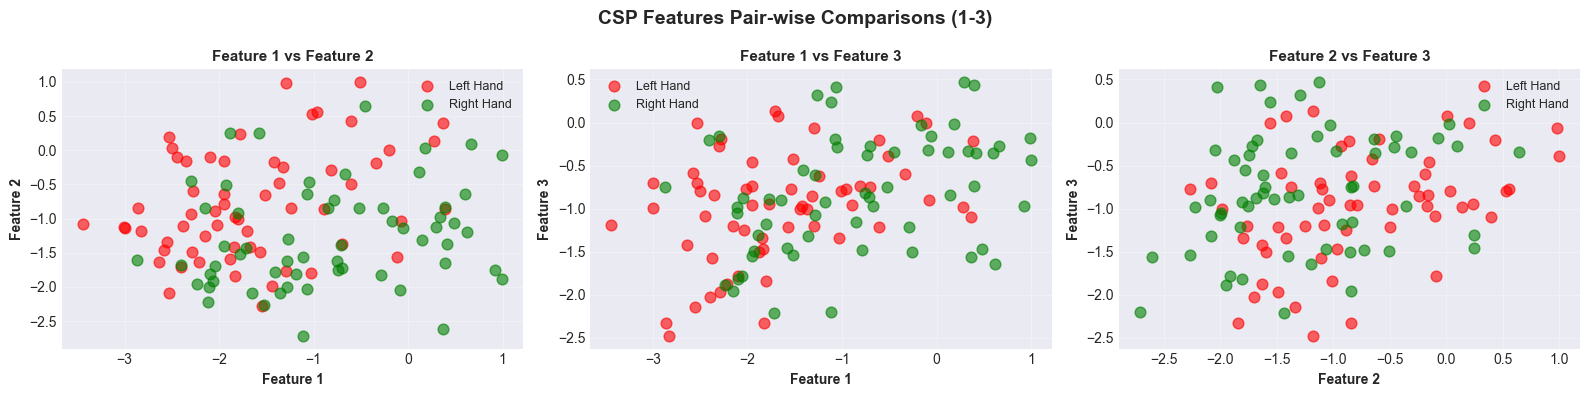


CSP FEATURES 1-3 SUMMARY STATISTICS

FEATURE 1:
  Left Hand  - Mean: -1.6415, Std:  0.8928, Range: [-3.4413,  0.3847]
  Right Hand - Mean: -0.8429, Std:  1.0146, Range: [-2.8688,  0.9963]
  Mean Diff:   0.7987

FEATURE 2:
  Left Hand  - Mean: -0.7969, Std:  0.7768, Range: [-2.2727,  0.9971]
  Right Hand - Mean: -1.2673, Std:  0.7392, Range: [-2.7157,  0.6436]
  Mean Diff:  -0.4704

FEATURE 3:
  Left Hand  - Mean: -0.9755, Std:  0.6270, Range: [-2.4756,  0.1317]
  Right Hand - Mean: -0.8158, Std:  0.6712, Range: [-2.2102,  0.4702]
  Mean Diff:   0.1597



In [195]:
# ==================== COMPREHENSIVE CSP FEATURES 1-3 VISUALIZATION ====================
from mpl_toolkits.mplot3d import Axes3D

# Prepare data
left_features = csp_features[y_csp == 0]
right_features = csp_features[y_csp == 1]

# ========== PAIR PLOTS: ALL COMBINATIONS ==========
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('CSP Features Pair-wise Comparisons (1-3)', fontsize=14, fontweight='bold')

# Feature 1 vs Feature 2
axes[0].scatter(left_features[:, 0], left_features[:, 1], 
               label='Left Hand', color='red', alpha=0.6, s=60)
axes[0].scatter(right_features[:, 0], right_features[:, 1], 
               label='Right Hand', color='green', alpha=0.6, s=60)
axes[0].set_xlabel('Feature 1', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Feature 2', fontsize=10, fontweight='bold')
axes[0].set_title('Feature 1 vs Feature 2', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Feature 1 vs Feature 3
axes[1].scatter(left_features[:, 0], left_features[:, 2], 
               label='Left Hand', color='red', alpha=0.6, s=60)
axes[1].scatter(right_features[:, 0], right_features[:, 2], 
               label='Right Hand', color='green', alpha=0.6, s=60)
axes[1].set_xlabel('Feature 1', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Feature 3', fontsize=10, fontweight='bold')
axes[1].set_title('Feature 1 vs Feature 3', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

# Feature 2 vs Feature 3
axes[2].scatter(left_features[:, 1], left_features[:, 2], 
               label='Left Hand', color='red', alpha=0.6, s=60)
axes[2].scatter(right_features[:, 1], right_features[:, 2], 
               label='Right Hand', color='green', alpha=0.6, s=60)
axes[2].set_xlabel('Feature 2', fontsize=10, fontweight='bold')
axes[2].set_ylabel('Feature 3', fontsize=10, fontweight='bold')
axes[2].set_title('Feature 2 vs Feature 3', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


# ========== FEATURE STATISTICS SUMMARY ==========
print("\n" + "="*70)
print("CSP FEATURES 1-3 SUMMARY STATISTICS")
print("="*70)

for feat_idx in range(3):
    left_data = left_features[:, feat_idx]
    right_data = right_features[:, feat_idx]
    
    print(f"\nFEATURE {feat_idx + 1}:")
    print(f"  Left Hand  - Mean: {np.mean(left_data):7.4f}, Std: {np.std(left_data):7.4f}, Range: [{np.min(left_data):7.4f}, {np.max(left_data):7.4f}]")
    print(f"  Right Hand - Mean: {np.mean(right_data):7.4f}, Std: {np.std(right_data):7.4f}, Range: [{np.min(right_data):7.4f}, {np.max(right_data):7.4f}]")
    print(f"  Mean Diff:  {np.mean(right_data) - np.mean(left_data):7.4f}")

print("\n" + "="*70)

In [196]:
import numpy as np

# X shape: (n_trials, n_channels, n_samples)
X = np.vstack([epochs_left_test, epochs_right_test])
y = np.hstack([
    np.zeros(len(epochs_left_test)),
    np.ones(len(epochs_right_test))
])


def compute_covariance(trial):
    # trial: (channels, samples)
    cov = trial @ trial.T
    return cov / np.trace(cov)


def mean_covariance(X, y, label):
    covs = [compute_covariance(X[i]) for i in range(len(y)) if y[i] == label]
    return np.mean(covs, axis=0)

cov_left  = mean_covariance(X, y, label=0)
cov_right = mean_covariance(X, y, label=1)


# Composite covariance
cov_total = cov_left + cov_right

# Eigen decomposition
eigvals, eigvecs = np.linalg.eig(
    np.linalg.pinv(cov_total) @ cov_left
)

# Sort eigenvectors
idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]


n_components = 4
W = eigvecs[:, :n_components]   # (channels, components)


def extract_csp_features(X, W):
    features = []
    for trial in X:
        Z = W.T @ trial
        var = np.var(Z, axis=1)
        features.append(np.log(var / np.sum(var)))
    return np.array(features)

csp_features = extract_csp_features(X, W)


print("CSP Features shape:", csp_features.shape)
print("First 5 trials:\n", csp_features[:5])


CSP Features shape: (120, 3)
First 5 trials:
 [[-0.58716551 -1.71178121 -1.33349194]
 [-1.03433399 -1.1604095  -1.10509589]
 [-1.36649693 -1.32685874 -0.73461112]
 [-1.90773913 -1.51900286 -0.45783104]
 [-1.90145231 -0.42266059 -1.6329756 ]]


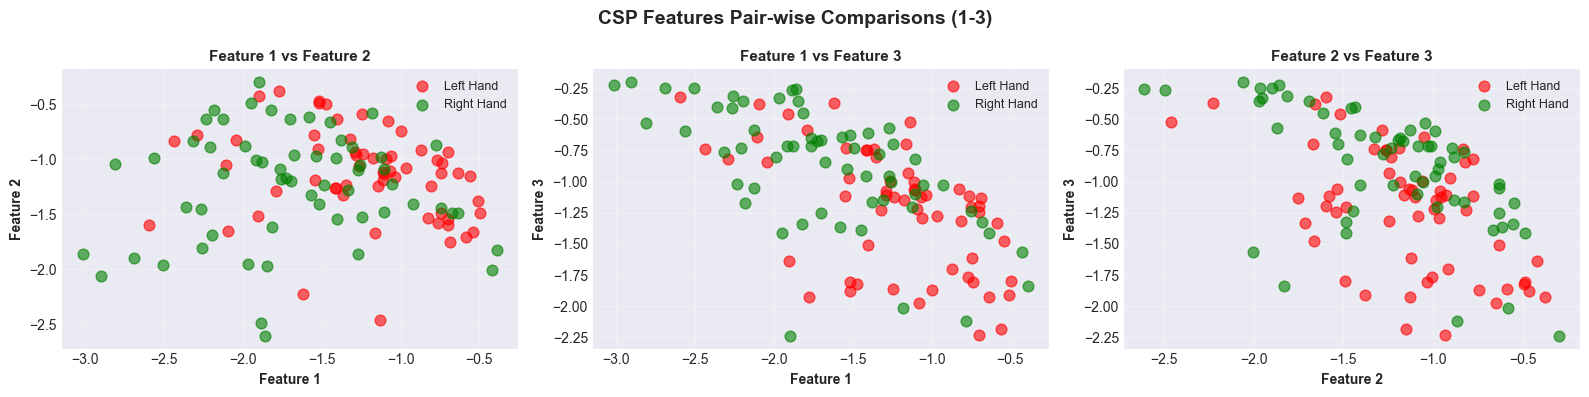


CSP FEATURES 1-3 SUMMARY STATISTICS

FEATURE 1:
  Left Hand  - Mean: -1.2314, Std:  0.4962, Range: [-2.5959, -0.4956]
  Right Hand - Mean: -1.6851, Std:  0.5950, Range: [-3.0177, -0.3855]
  Mean Diff:  -0.4536

FEATURE 2:
  Left Hand  - Mean: -1.1448, Std:  0.4130, Range: [-2.4598, -0.3785]
  Right Hand - Mean: -1.2527, Std:  0.5025, Range: [-2.6074, -0.2970]
  Mean Diff:  -0.1079

FEATURE 3:
  Left Hand  - Mean: -1.2209, Std:  0.4838, Range: [-2.2297, -0.3251]
  Right Hand - Mean: -0.8791, Std:  0.4737, Range: [-2.2371, -0.2012]
  Mean Diff:   0.3418



In [197]:
# ==================== COMPREHENSIVE CSP FEATURES 1-3 VISUALIZATION ====================
from mpl_toolkits.mplot3d import Axes3D

# Prepare data
left_features = csp_features[y_csp == 0]
right_features = csp_features[y_csp == 1]


# ========== PAIR PLOTS: ALL COMBINATIONS ==========
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('CSP Features Pair-wise Comparisons (1-3)', fontsize=14, fontweight='bold')

# Feature 1 vs Feature 2
axes[0].scatter(left_features[:, 0], left_features[:, 1], 
               label='Left Hand', color='red', alpha=0.6, s=60)
axes[0].scatter(right_features[:, 0], right_features[:, 1], 
               label='Right Hand', color='green', alpha=0.6, s=60)
axes[0].set_xlabel('Feature 1', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Feature 2', fontsize=10, fontweight='bold')
axes[0].set_title('Feature 1 vs Feature 2', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Feature 1 vs Feature 3
axes[1].scatter(left_features[:, 0], left_features[:, 2], 
               label='Left Hand', color='red', alpha=0.6, s=60)
axes[1].scatter(right_features[:, 0], right_features[:, 2], 
               label='Right Hand', color='green', alpha=0.6, s=60)
axes[1].set_xlabel('Feature 1', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Feature 3', fontsize=10, fontweight='bold')
axes[1].set_title('Feature 1 vs Feature 3', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

# Feature 2 vs Feature 3
axes[2].scatter(left_features[:, 1], left_features[:, 2], 
               label='Left Hand', color='red', alpha=0.6, s=60)
axes[2].scatter(right_features[:, 1], right_features[:, 2], 
               label='Right Hand', color='green', alpha=0.6, s=60)
axes[2].set_xlabel('Feature 2', fontsize=10, fontweight='bold')
axes[2].set_ylabel('Feature 3', fontsize=10, fontweight='bold')
axes[2].set_title('Feature 2 vs Feature 3', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


# ========== FEATURE STATISTICS SUMMARY ==========
print("\n" + "="*70)
print("CSP FEATURES 1-3 SUMMARY STATISTICS")
print("="*70)

for feat_idx in range(3):
    left_data = left_features[:, feat_idx]
    right_data = right_features[:, feat_idx]
    
    print(f"\nFEATURE {feat_idx + 1}:")
    print(f"  Left Hand  - Mean: {np.mean(left_data):7.4f}, Std: {np.std(left_data):7.4f}, Range: [{np.min(left_data):7.4f}, {np.max(left_data):7.4f}]")
    print(f"  Right Hand - Mean: {np.mean(right_data):7.4f}, Std: {np.std(right_data):7.4f}, Range: [{np.min(right_data):7.4f}, {np.max(right_data):7.4f}]")
    print(f"  Mean Diff:  {np.mean(right_data) - np.mean(left_data):7.4f}")

print("\n" + "="*70)
